# Annotation Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read annotation file
df_annotation = pd.read_csv('../data/annotations_combined.csv')
df_annotation.head()

,img_id,group_id,hair_1,pen_1,hair_2,pen_2,hair_3,pen_3,hair_4,pen_4,hair_5,pen_5
0,PAT_1431_1495_511.png,a,2.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,NaN,NaN
1,PAT_2051_4356_460.png,a,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN
2,PAT_1255_876_939.png,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN
3,PAT_963_1820_823.png,a,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,NaN
4,PAT_419_832_706.png,a,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,NaN,NaN


In [14]:
# preprocessing annotations

# keep only relevant cols
df_annotation.drop(columns = 'group_id', inplace = True) 
df_annotation.drop_duplicates(inplace = True)

print('Before')
print(f'cols: {df_annotation.shape[1]}, rows: {df_annotation.shape[0]}')

# drop rows with all NA values
df_annotation.dropna(how='all', inplace = True)

print(df_annotation.head())

print()

# change all NA values to 0
df_annotation.fillna(value = 0, inplace = True)

print('After')
print(f'cols: {df_annotation.shape[1]}, rows: {df_annotation.shape[0]}')
print(df_annotation.head())

Before
cols: 11, rows: 1637
                  img_id  hair_1  pen_1  hair_2  pen_2  hair_3  pen_3  hair_4  \
0  PAT_1431_1495_511.png     2.0    0.0     1.0    0.0     2.0    0.0     1.0   
1  PAT_2051_4356_460.png     2.0    1.0     1.0    1.0     1.0    1.0     1.0   
2   PAT_1255_876_939.png     0.0    0.0     0.0    0.0     0.0    0.0     0.0   
3   PAT_963_1820_823.png     1.0    0.0     1.0    0.0     1.0    0.0     0.0   
4    PAT_419_832_706.png     0.0    1.0     0.0    1.0     0.0    1.0     0.0   

   pen_4  hair_5  pen_5  
0    0.0     NaN    NaN  
1    0.0     NaN    NaN  
2    1.0     NaN    NaN  
3    1.0     NaN    NaN  
4    1.0     NaN    NaN  

After
cols: 11, rows: 1636
                  img_id  hair_1  pen_1  hair_2  pen_2  hair_3  pen_3  hair_4  \
0  PAT_1431_1495_511.png     2.0    0.0     1.0    0.0     2.0    0.0     1.0   
1  PAT_2051_4356_460.png     2.0    1.0     1.0    1.0     1.0    1.0     1.0   
2   PAT_1255_876_939.png     0.0    0.0     0.0    0.0    

In [15]:
# Separate columns for hair and pen marks
hair_cols = [col for col in df_annotation.columns if "hair" in col]
pen_cols = [col for col in df_annotation.columns if "pen" in col]


# modify annotations (voting)
df_annotation['hair_rating'] =df_annotation[hair_cols].apply(
    lambda row: row.mode().max(), axis=1
)
df_annotation['pen_rating'] =df_annotation[pen_cols].apply(
    lambda row: row.mode().max(), axis=1
)

In [17]:
# Agreement Score

def agreement_score(row):
    return row.value_counts(normalize=True).max()

df_annotation["hair_agreement"] = df_annotation[hair_cols].apply(agreement_score, axis=1)
df_annotation["pen_agreement"] = df_annotation[pen_cols].apply(agreement_score, axis=1)

Interpretation:

- 1.0 → full agreement
- 0.6 → moderate agreement
- 0.2–0.4 → low agreement

In [22]:
# Cases when annotators disagree

low_agreement = df_annotation[
    (df_annotation["hair_agreement"] < 0.6) |
    (df_annotation["pen_agreement"] < 0.6)
]

low_agreement 

,img_id,hair_1,pen_1,hair_2,pen_2,hair_3,pen_3,hair_4,pen_4,hair_5,pen_5,hair_rating,pen_rating,hair_agreement,pen_agreement
0,PAT_1431_1495_511.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.4,1.0
6,PAT_1701_3135_5.png,3.0,0.0,2.0,0.0,3.0,0.0,2.0,1.0,0.0,0.0,3.0,0.0,0.4,0.8
7,PAT_216_331_678.png,3.0,0.0,1.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0,3.0,0.0,0.4,0.6
12,PAT_372_760_267.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.4,0.8
16,PAT_1947_3926_165.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.4,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,PAT_961_1818_992,3.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,0.4,1.0
1249,PAT_966_1825_584,3.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,0.4,1.0
1282,PAT_2016_4160_868,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.4,1.0
1554,PAT_330_1440_532.png,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,0.0,1.0,0.0,0.4,0.8


In [23]:
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np

def compute_fleiss_kappa(df_subset):
    categories = sorted(pd.unique(df_subset.values.ravel()))
    
    matrix = []
    for _, row in df_subset.iterrows():
        counts = row.value_counts()
        row_counts = [counts.get(cat, 0) for cat in categories]
        matrix.append(row_counts)
    
    return fleiss_kappa(np.array(matrix))

hair_kappa = compute_fleiss_kappa(df_annotation[hair_cols])
pen_kappa = compute_fleiss_kappa(df_annotation[pen_cols])

print("Hair Fleiss' Kappa:", hair_kappa)
print("Pen Fleiss' Kappa:", pen_kappa)

Hair Fleiss' Kappa: 0.6271427161893804
Pen Fleiss' Kappa: 0.8161175030892192


In [24]:
print("Hair agreement mean:", df_annotation["hair_agreement"].mean())
print("Pen agreement mean:", df_annotation["pen_agreement"].mean())

Hair agreement mean: 0.8553789731051346
Pen agreement mean: 0.962591687041565


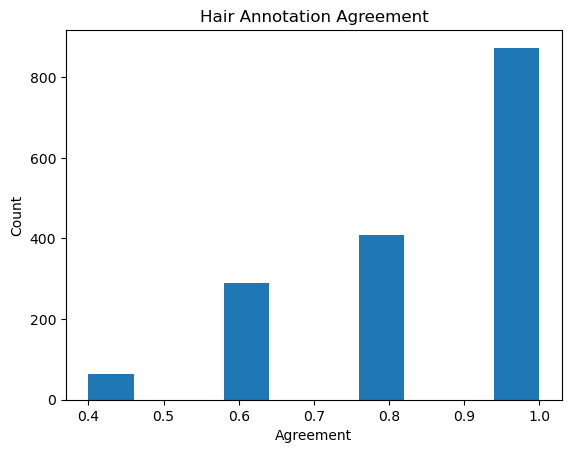

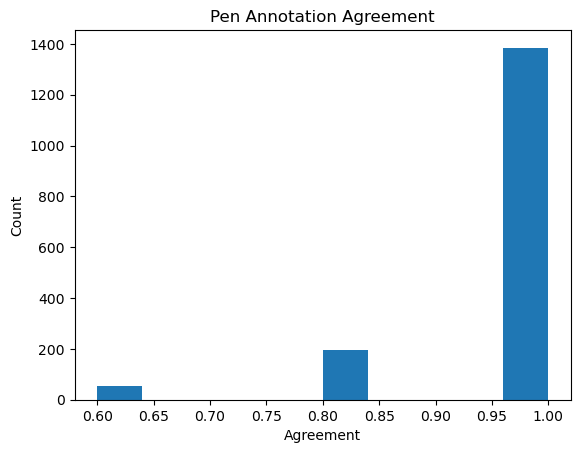

In [25]:
import matplotlib.pyplot as plt

plt.hist(df_annotation["hair_agreement"], bins=10)
plt.title("Hair Annotation Agreement")
plt.xlabel("Agreement")
plt.ylabel("Count")
plt.show()

plt.hist(df_annotation["pen_agreement"], bins=10)
plt.title("Pen Annotation Agreement")
plt.xlabel("Agreement")
plt.ylabel("Count")
plt.show()

In [27]:
for col in hair_cols:
    agreement = (df_annotation[col] == df_annotation["hair_rating"]).mean()
    print(f"{col} vs majority:", agreement)

hair_1 vs majority: 0.8661369193154034
hair_2 vs majority: 0.8429095354523227
hair_3 vs majority: 0.878361858190709
hair_4 vs majority: 0.8636919315403423
hair_5 vs majority: 0.8257946210268948


          hair_1    hair_2    hair_3    hair_4    hair_5
hair_1  1.000000  0.792176  0.770171  0.759780  0.728606
hair_2  0.792176  1.000000  0.755501  0.751222  0.735330
hair_3  0.770171  0.755501  1.000000  0.818460  0.742665
hair_4  0.759780  0.751222  0.818460  1.000000  0.740220
hair_5  0.728606  0.735330  0.742665  0.740220  1.000000


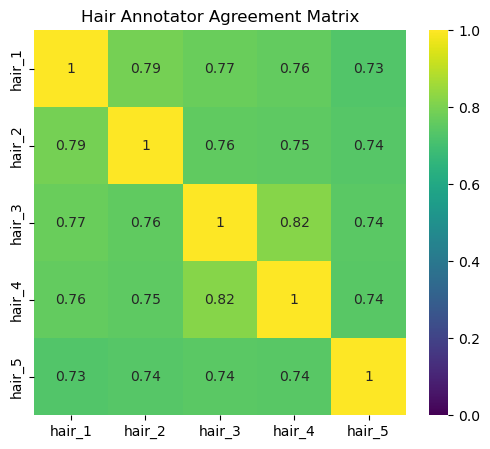

In [ ]:
# with 2 annotators (hair annotations)
hair_cols = ['hair_1', 'hair_2', 'hair_3', 'hair_4', 'hair_5']
hair_df = df_annotation[hair_cols]

# Compute agreement matrix

import pandas as pd

def agreement_matrix(df_subset):
    cols = df_subset.columns
    matrix = pd.DataFrame(index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            agreement = (df_subset[col1] == df_subset[col2]).mean()
            matrix.loc[col1, col2] = agreement

    return matrix.astype(float)

hair_agreement_matrix = agreement_matrix(hair_df)

print(hair_agreement_matrix)

# Visualisation as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(hair_agreement_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)

plt.title("Hair Annotator Agreement Matrix")
plt.show()

In [33]:
df_annotation.columns

Index(['img_id', 'hair_1', 'pen_1', 'hair_2', 'pen_2', 'hair_3', 'pen_3',
       'hair_4', 'pen_4', 'hair_5', 'pen_5', 'hair_rating', 'pen_rating',
       'hair_agreement', 'pen_agreement'],
      dtype='str')

          pen_1     pen_2     pen_3     pen_4     pen_5
pen_1  1.000000  0.963325  0.966381  0.905868  0.951711
pen_2  0.963325  1.000000  0.954156  0.897311  0.949267
pen_3  0.966381  0.954156  1.000000  0.902812  0.941320
pen_4  0.905868  0.897311  0.902812  1.000000  0.886919
pen_5  0.951711  0.949267  0.941320  0.886919  1.000000


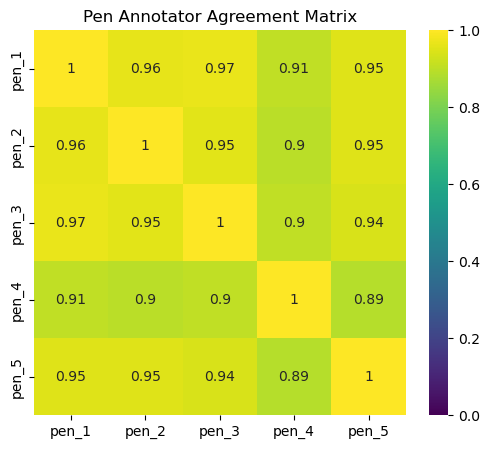

In [34]:
# with 2 annotators (pen marks)
pen_cols = ['pen_1', 'pen_2', 'pen_3', 'pen_4', 'pen_5']
pen_df = df_annotation[pen_cols]

pen_agreement_matrix = agreement_matrix(pen_df)

print(pen_agreement_matrix)

# Visualisation as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(pen_agreement_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)

plt.title("Pen Annotator Agreement Matrix")
plt.show()

          hair_1    hair_2    hair_3    hair_4    hair_5
hair_1  1.000000  0.680404  0.645957  0.628274  0.575375
hair_2  0.680404  1.000000  0.624342  0.615755  0.588535
hair_3  0.645957  0.624342  1.000000  0.719413  0.599241
hair_4  0.628274  0.615755  0.719413  1.000000  0.593423
hair_5  0.575375  0.588535  0.599241  0.593423  1.000000


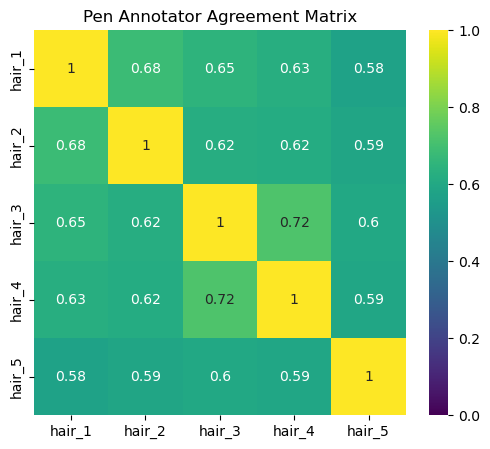

In [37]:
from sklearn.metrics import cohen_kappa_score

def kappa_matrix(df_subset):
    cols = df_subset.columns
    matrix = pd.DataFrame(index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            score = cohen_kappa_score(df_subset[col1], df_subset[col2])
            matrix.loc[col1, col2] = score

    return matrix.astype(float)

hair_kappa_matrix = kappa_matrix(hair_df)

print(hair_kappa_matrix)

# Visualisation as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(hair_kappa_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)

plt.title("Pen Annotator Agreement Matrix")
plt.show()

          pen_1     pen_2     pen_3     pen_4     pen_5
pen_1  1.000000  0.899529  0.908373  0.755696  0.864779
pen_2  0.899529  1.000000  0.874839  0.733112  0.857664
pen_3  0.908373  0.874839  1.000000  0.748516  0.836270
pen_4  0.755696  0.733112  0.748516  1.000000  0.700847
pen_5  0.864779  0.857664  0.836270  0.700847  1.000000


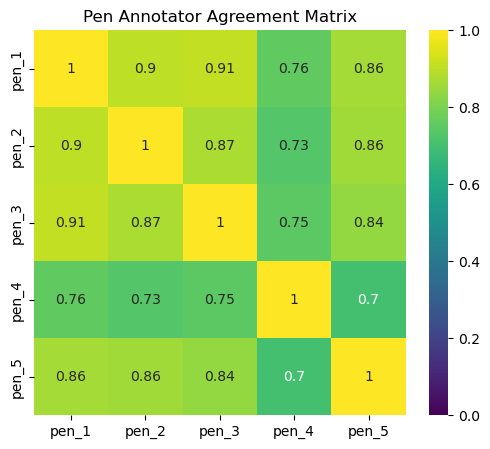

In [38]:
pen_kappa_matrix = kappa_matrix(pen_df)

print(pen_kappa_matrix)

# Visualisation as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(pen_kappa_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)

plt.title("Pen Annotator Agreement Matrix")
plt.show()

In [8]:
def show_rgb_channel(img_id):
    img_path = '../data/imgs/' + img_id
    img_rgb = plt.imread(img_path)
    channel = ['red', 'green', 'blue']

    fig, ax = plt.subplots(1,3, figsize = (10,8))

    for i in range(3):
        ax[i].imshow(img_rgb[:,:,i], cmap = 'grey')
        ax[i].set_title(f'{channel[i]} channel')
        ax[i].axis('off')
    
    plt.tight_layout()
    plt.show()

    return